# Heart Disease Machine Learning Lifecycle

This notebook demonstrates the end-to-end machine learning lifecycle for predicting heart disease. We will evaluate four different algorithms separately: Logistic Regression, Random Forest, Decision Tree, and K-Nearest Neighbors (KNN).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

# Set seaborn style for better visuals
sns.set_theme(style="whitegrid")

## 2. Data Loading & Understanding

In [2]:
# Use an absolute path or relative path from the current working directory
data_path = 'heart_disease_data.csv'
if not os.path.exists(data_path):
    # Fallback to absolute path just in case we run it from root
    data_path = os.path.abspath(os.path.join('model', 'heart_disease_data.csv'))

df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 2.1 Exploratory Data Analysis (EDA) & Data Visualisation

C:\Users\umang\AppData\Local\Temp\ipykernel_9948\4090788291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


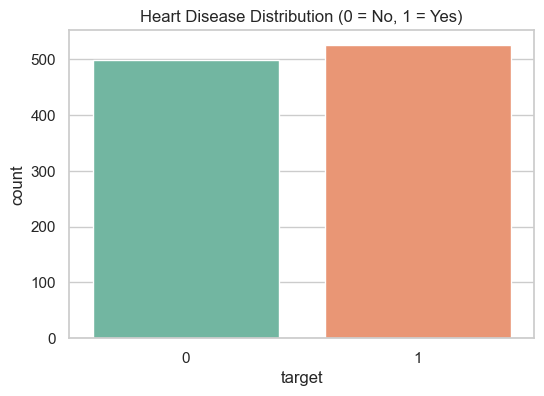

In [3]:
# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.show()

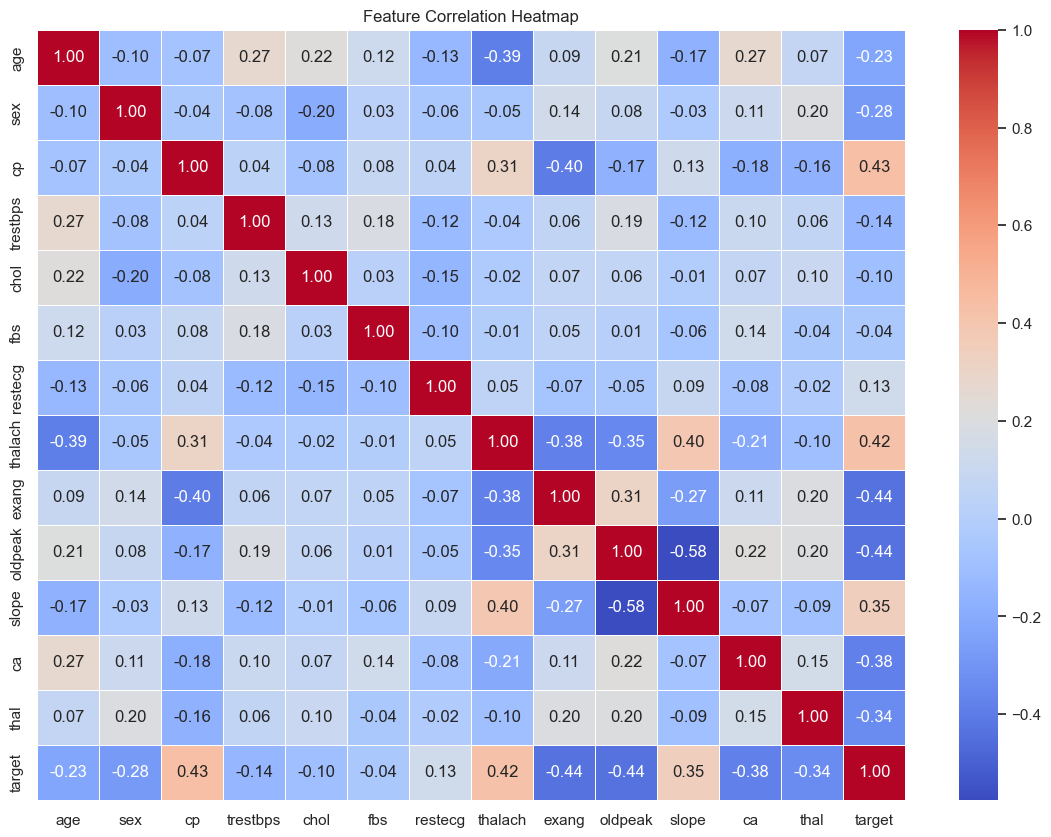

In [4]:
# 2. Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

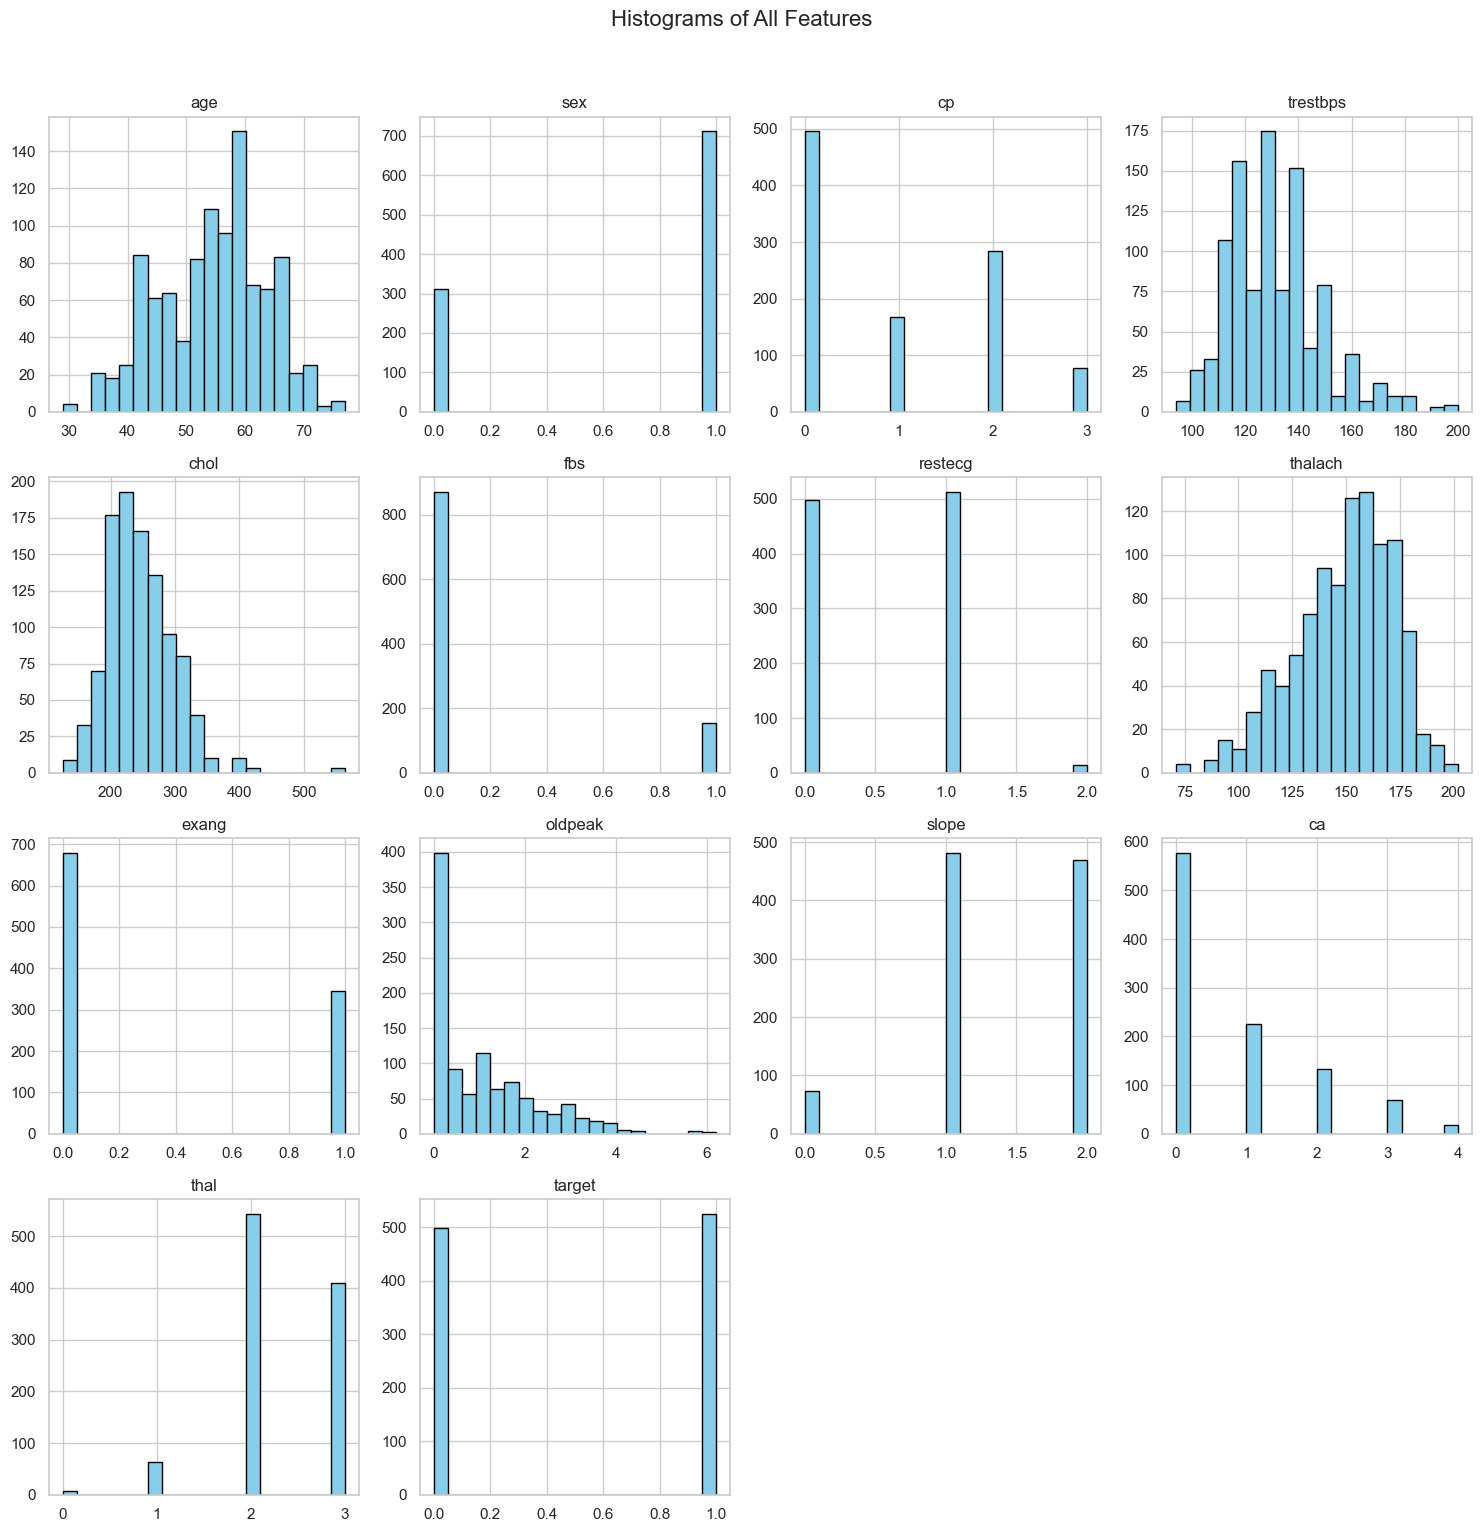

In [5]:
# 3. Histograms of Numerical Features
df.hist(figsize=(15, 15), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing
- Check for missing values
- Separate features (X) and target (y)
- Perform Train/Test Split
- Scale features (Important for KNN and Logistic Regression)

In [6]:
# Drop missing values if any
if df.isnull().sum().any():
    print("Missing values detected. Dropping rows...")
    df = df.dropna()

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (820, 13)
Testing data shape: (205, 13)


## 4. Model Building & Evaluation (Separate Algorithms)

### 4.1 Logistic Regression

In [7]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7951

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



### 4.2 Random Forest

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Unscaled data
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9854

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### 4.3 Decision Tree

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train) # Unscaled data
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9854

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### 4.4 K-Nearest Neighbors (KNN)

In [10]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8341



Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



## 5. Save Best Model
Based on the results, Random Forest is our best performing model. We'll save it to disk along with the scaler.

In [11]:
best_model = rf_model

# Ensure the 'model' directory exists (if running from root)
save_dir = '.'
if os.path.exists('model') and os.path.isdir('model'):
    save_dir = 'model'

joblib.dump(best_model, os.path.join(save_dir, 'best_heart_disease_model.pkl'))
joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))

print("Successfully saved Random Forest model and Scaler to disk.")

Successfully saved Random Forest model and Scaler to disk.
